# Forecasting GB Wind Generation from Weather Data

Arnas Jankauskas

**Runtime:** about 9 minutes from a fresh runtime, most of it the grid search in section 8.
`random_state=42` throughout.

## 1. Setup and data collection

### 1.1 Imports and generation data

In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              VotingClassifier)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score)

URL_2025 = ("https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/"
            "resource/b2bde559-3455-4021-b179-dfe60c0337b0/download/demanddata_2025.csv")

neso = pd.read_csv(URL_2025)

print("shape:", neso.shape)
print("columns:", neso.columns.tolist())
print()
print(neso[["SETTLEMENT_DATE", "SETTLEMENT_PERIOD", "EMBEDDED_WIND_GENERATION",
            "EMBEDDED_WIND_CAPACITY"]].head(3).to_string())

shape: (17520, 22)
columns: ['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING', 'SCOTTISH_TRANSFER', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW', 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW']

  SETTLEMENT_DATE  SETTLEMENT_PERIOD  EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY
0      2025-01-01                  1                      5405                    6606
1      2025-01-01                  2                      5358                    6606
2      2025-01-01                  3                      5237                    6606


### 1.2 Which clock are the timestamps on?

NESO gives a settlement date plus a period number; Open-Meteo returns UTC. The row count cannot
settle which clock NESO uses. Counting
periods per day can.

In [ ]:
counts = neso.groupby("SETTLEMENT_DATE").size()

print("period counts per day:", counts.value_counts().to_dict())
print("\ndays that are not 48 periods:")
print(counts[counts != 48])

period counts per day: {48: 363, 46: 1, 50: 1}

days that are not 48 periods:
SETTLEMENT_DATE
2025-03-30    46
2025-10-26    50
dtype: int64


### 1.3 Weather data

Four locations across the main GB onshore wind regions. Cloud cover and shortwave radiation are
included as controls: they drive solar rather than wind, so feature importance should rank them near
the bottom.

In [ ]:
SITES = {
    "s_scotland": (55.5, -4.0),
    "n_england":  (54.5, -2.0),
    "wales":      (52.5, -3.5),
    "sw_england": (50.8, -4.0),
}

frames = []
for name, coords in SITES.items():
    lat, lon = coords[0], coords[1]
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
        "latitude": lat,
        "longitude": lon,
        "start_date": "2025-01-01",
        "end_date": "2025-12-31",
        "hourly": ("wind_speed_100m,wind_speed_10m,temperature_2m,"
                   "surface_pressure,cloud_cover,shortwave_radiation,"
                   "wind_direction_100m,wind_gusts_10m"),
        "wind_speed_unit": "ms",
        "timezone": "UTC",
    })
    r.raise_for_status()
    df_site = pd.DataFrame(r.json()["hourly"])
    df_site["site"] = name
    frames.append(df_site)
    print(name, df_site.shape, "max 100m wind (m/s):",
          round(df_site["wind_speed_100m"].max(), 1))

weather = pd.concat(frames, ignore_index=True)
weather["time"] = pd.to_datetime(weather["time"], utc=True)
print("\nweather:", weather.shape)

s_scotland (8760, 10) max 100m wind (m/s): 26.3
n_england (8760, 10) max 100m wind (m/s): 23.7
wales (8760, 10) max 100m wind (m/s): 22.0
sw_england (8760, 10) max 100m wind (m/s): 23.9

weather: (35040, 10)


## 2. Cleaning and preprocessing

### 2.1 Settlement periods to UTC

In [ ]:
# Local midnight is unambiguous (clock changes happen at 01:00).
day_start = (pd.to_datetime(neso["SETTLEMENT_DATE"])
             .dt.tz_localize("Europe/London")
             .dt.tz_convert("UTC"))

# Period p covers the half hour starting (p-1)*30 minutes after the day's start.
neso["time"] = day_start + pd.to_timedelta(
    (neso["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")

print("monotonic: ", neso["time"].is_monotonic_increasing)
print("duplicates:", neso["time"].duplicated().sum())

for date in ["2025-03-30", "2025-10-26"]:
    sub = neso[neso["SETTLEMENT_DATE"] == date]
    print(date, "| periods:", len(sub),
          "| first:", sub["time"].iloc[0], "| last:", sub["time"].iloc[-1])

monotonic:  True
duplicates: 0
2025-03-30 | periods: 46 | first: 2025-03-30 00:00:00+00:00 | last: 2025-03-30 22:30:00+00:00
2025-10-26 | periods: 50 | first: 2025-10-25 23:00:00+00:00 | last: 2025-10-26 23:30:00+00:00


### 2.2 Merging, and converting to capacity factor

In [ ]:
n = neso[["time", "EMBEDDED_WIND_GENERATION", "EMBEDDED_WIND_CAPACITY"]].copy()
n["wind_cf"] = n["EMBEDDED_WIND_GENERATION"] / n["EMBEDDED_WIND_CAPACITY"]

# Two settlement periods per hour, averaged into one hourly value.
n_hourly = n.set_index("time").resample("h").mean().reset_index()

# Four sites averaged into one GB-wide value per hour.
w_hourly = weather.drop(columns=["site"]).groupby("time").mean().reset_index()

df = pd.merge(n_hourly, w_hourly, on="time", how="inner")

print("neso hourly:", n_hourly.shape,
      "| weather hourly:", w_hourly.shape,
      "| merged:", df.shape)
print("capacity factor range:", round(df["wind_cf"].min(), 3),
      "to", round(df["wind_cf"].max(), 3))
print("duplicate rows:      ", df.duplicated().sum())
print("duplicate timestamps:", df["time"].duplicated().sum())
print("missing values:      ", df.isna().sum().sum())

neso hourly: (8760, 4) | weather hourly: (8760, 9) | merged: (8760, 12)
capacity factor range: 0.019 to 0.895
duplicate rows:       0
duplicate timestamps: 0
missing values:       0


## 3. Exploratory data analysis

Checks whether the physical power curve shows up, whether there is seasonality
or are there gaps, what shape the target takes, and which features move with it.

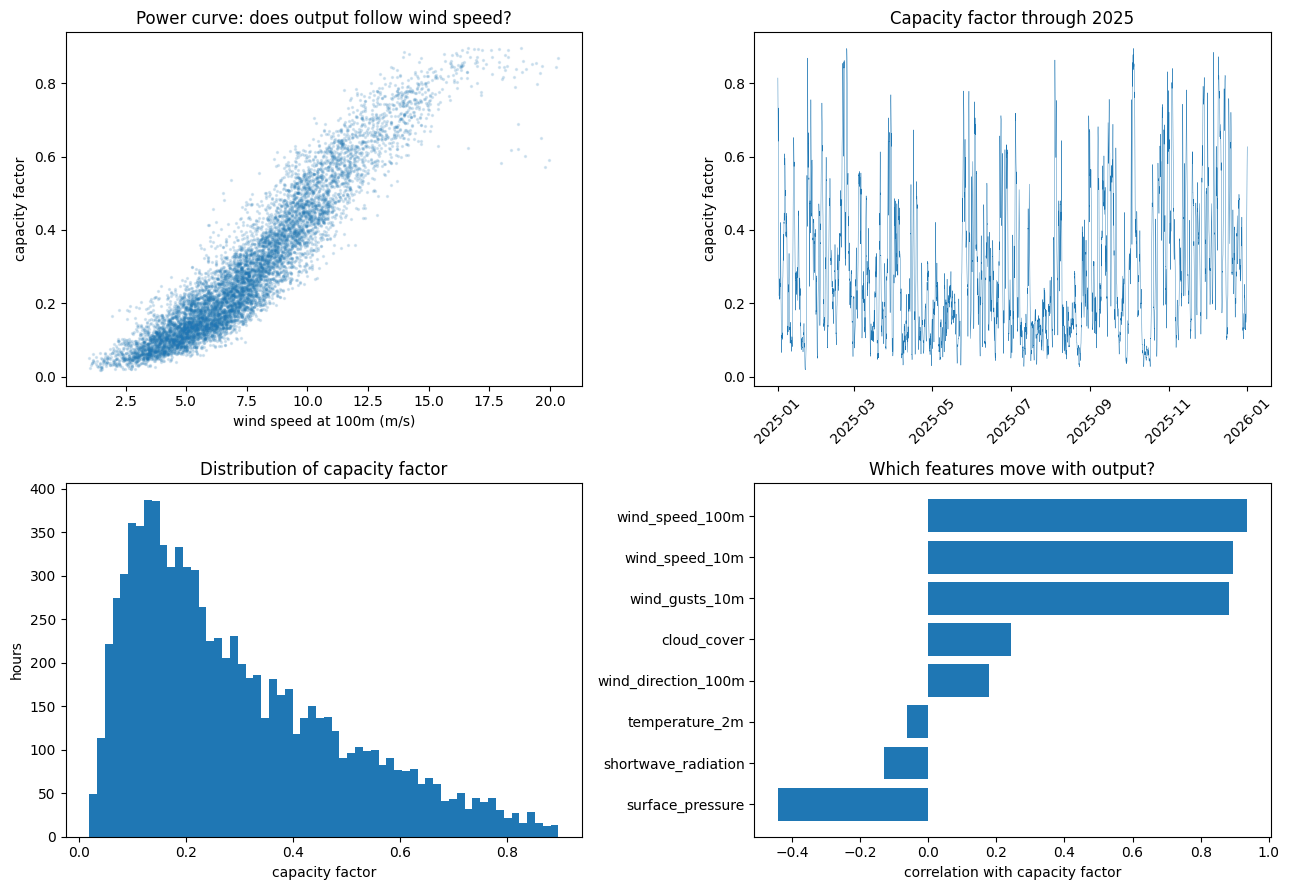

surface_pressure      -0.441
shortwave_radiation   -0.129
temperature_2m        -0.062
wind_direction_100m    0.179
cloud_cover            0.242
wind_gusts_10m         0.883
wind_speed_10m         0.896
wind_speed_100m        0.937


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].scatter(df["wind_speed_100m"], df["wind_cf"], s=2, alpha=0.15)
axes[0, 0].set_xlabel("wind speed at 100m (m/s)")
axes[0, 0].set_ylabel("capacity factor")
axes[0, 0].set_title("Power curve: does output follow wind speed?")

axes[0, 1].plot(df["time"], df["wind_cf"], lw=0.3)
axes[0, 1].set_ylabel("capacity factor")
axes[0, 1].set_title("Capacity factor through 2025")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].hist(df["wind_cf"], bins=60)
axes[1, 0].set_xlabel("capacity factor")
axes[1, 0].set_ylabel("hours")
axes[1, 0].set_title("Distribution of capacity factor")

feats = ["wind_speed_100m", "wind_speed_10m", "wind_gusts_10m", "temperature_2m",
         "surface_pressure", "cloud_cover", "shortwave_radiation", "wind_direction_100m"]
corr = df[feats + ["wind_cf"]].corr()["wind_cf"].drop("wind_cf").sort_values()
axes[1, 1].barh(corr.index, corr.values)
axes[1, 1].set_xlabel("correlation with capacity factor")
axes[1, 1].set_title("Which features move with output?")

plt.tight_layout()
plt.show()

print(corr.round(3).to_string())

## 4. Feature engineering and target definition

Three targets of increasing difficulty, built from the same features.

In [ ]:
H = 6  # forecast horizon, in hours

d = df.sort_values("time").reset_index(drop=True).copy()

# --- Engineered features ---
rad = np.deg2rad(d["wind_direction_100m"])
d["wind_dir_sin"] = np.sin(rad)
d["wind_dir_cos"] = np.cos(rad)

d["wind_speed_100m_cubed"] = d["wind_speed_100m"] ** 3   # P proportional to v^3
d["gust_ratio"]  = d["wind_gusts_10m"] / d["wind_speed_10m"]     # turbulence proxy
d["shear_ratio"] = d["wind_speed_100m"] / d["wind_speed_10m"]    # how fast wind rises with height

hour = d["time"].dt.hour
doy = d["time"].dt.dayofyear
d["hour_sin"] = np.sin(2 * np.pi * hour / 24)
d["hour_cos"] = np.cos(2 * np.pi * hour / 24)
d["doy_sin"]  = np.sin(2 * np.pi * doy / 365)
d["doy_cos"]  = np.cos(2 * np.pi * doy / 365)

# --- Targets ---
d["cf_future"] = d["wind_cf"].shift(-H)          # output H hours from now
d["cf_change"] = d["cf_future"] - d["wind_cf"]

# A: which tercile is output in right now?
d["y_now"] = pd.qcut(d["wind_cf"], 3, labels=["low", "med", "high"])

# B: which tercile will output be in H hours?
d["y_future"] = pd.qcut(d["cf_future"], 3, labels=["low", "med", "high"])

# C: will output fall, hold steady, or rise?
lo, hi = d["cf_change"].quantile([0.20, 0.80])
d["y_ramp"] = pd.cut(d["cf_change"], bins=[-np.inf, lo, hi, np.inf],
                     labels=["down", "flat", "up"])

# The last H rows have no future to look at.
d = d.dropna(subset=["cf_future"]).reset_index(drop=True)

print("rows:", len(d))
print("ramp thresholds:", round(lo, 4), round(hi, 4))
print("\nclass balance:")
for col in ["y_now", "y_future", "y_ramp"]:
    print(" ", col, dict(d[col].value_counts()))

print("\nwind_speed_100m correlates with:")
print("  current cf:", round(d["wind_speed_100m"].corr(d["wind_cf"]), 3))
print("  future cf: ", round(d["wind_speed_100m"].corr(d["cf_future"]), 3))
print("  cf change: ", round(d["wind_speed_100m"].corr(d["cf_change"]), 3))

rows: 8754
ramp thresholds: -0.0657 0.0655

class balance:
  y_now {'low': np.int64(2922), 'med': np.int64(2919), 'high': np.int64(2913)}
  y_future {'low': np.int64(2918), 'med': np.int64(2918), 'high': np.int64(2918)}
  y_ramp {'flat': np.int64(5252), 'down': np.int64(1751), 'up': np.int64(1751)}

wind_speed_100m correlates with:
  current cf: 0.937
  future cf:  0.843
  cf change:  -0.186


### 4.1 Verifying the shift direction

A sign error here would invalidate everything downstream and produce no error message.
Row 0's `cf_future` should equal row 6's `wind_cf`.

In [ ]:
print(d[["time", "wind_cf", "cf_future"]].head(8).to_string())

                       time   wind_cf  cf_future
0 2025-01-01 00:00:00+00:00  0.814638   0.642219
1 2025-01-01 01:00:00+00:00  0.783530   0.650167
2 2025-01-01 02:00:00+00:00  0.766273   0.716318
3 2025-01-01 03:00:00+00:00  0.747200   0.732819
4 2025-01-01 04:00:00+00:00  0.722449   0.704814
5 2025-01-01 05:00:00+00:00  0.685059   0.661974
6 2025-01-01 06:00:00+00:00  0.642219   0.644187
7 2025-01-01 07:00:00+00:00  0.650167   0.588783


## 5. Train-test split

Splitting by whole day rather than by row, because consecutive hours are nearly identical and a
row-level shuffle would put a test hour's neighbour into training. Days are drawn from across the
whole year so both sets stay seasonally balanced.

In [ ]:
FEATURES = [
    "wind_speed_100m", "wind_speed_10m", "wind_gusts_10m", "wind_speed_100m_cubed",
    "surface_pressure", "temperature_2m", "cloud_cover", "shortwave_radiation",
    "wind_dir_sin", "wind_dir_cos", "gust_ratio", "shear_ratio",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "wind_cf",
]

# Target A predicts the tercile OF wind_cf, so including wind_cf gives the answer.
FEATURES_NOW = [f for f in FEATURES if f != "wind_cf"]

d["day"] = d["time"].dt.date
days = d["day"].unique()

train_days, test_days = train_test_split(days, test_size=0.2, random_state=42)
train_days, test_days = set(train_days), set(test_days)

train_mask = d["day"].isin(train_days)
test_mask  = d["day"].isin(test_days)

X_train, X_test = d.loc[train_mask, FEATURES], d.loc[test_mask, FEATURES]
y_train, y_test = d.loc[train_mask, "y_future"], d.loc[test_mask, "y_future"]

print("train days:", len(train_days), "| test days:", len(test_days))
print("train rows:", len(X_train), "| test rows:", len(X_test))
print("train months:", sorted(d.loc[train_mask, "time"].dt.month.unique()))
print("test months: ", sorted(d.loc[test_mask,  "time"].dt.month.unique()))

train days: 292 | test days: 73
train rows: 7002 | test rows: 1752
train months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
test months:  [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


### 5.1 Measuring the leakage

The same decision tree at seven depths, evaluated on both splits.

In [ ]:
# The leaky comparison: mixes adjacent hours across the split.
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    d[FEATURES], d["y_future"], test_size=0.2, random_state=42, shuffle=True)

depths = [2, 4, 6, 8, 12, 16, None]
honest_scores, leaky_scores = [], []

for depth in depths:
    t_honest = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    t_leaky  = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(Xs_tr, ys_tr)
    h = t_honest.score(X_test, y_test)
    l = t_leaky.score(Xs_te, ys_te)
    honest_scores.append(h)
    leaky_scores.append(l)
    print(f"depth={str(depth):>4}  honest={h:.3f}  leaky={l:.3f}  gap={l - h:+.3f}")

depth=   2  honest=0.764  leaky=0.725  gap=-0.038
depth=   4  honest=0.759  leaky=0.749  gap=-0.010
depth=   6  honest=0.735  leaky=0.762  gap=+0.027
depth=   8  honest=0.737  leaky=0.752  gap=+0.015
depth=  12  honest=0.724  leaky=0.771  gap=+0.047
depth=  16  honest=0.717  leaky=0.777  gap=+0.060
depth=None  honest=0.711  leaky=0.781  gap=+0.070


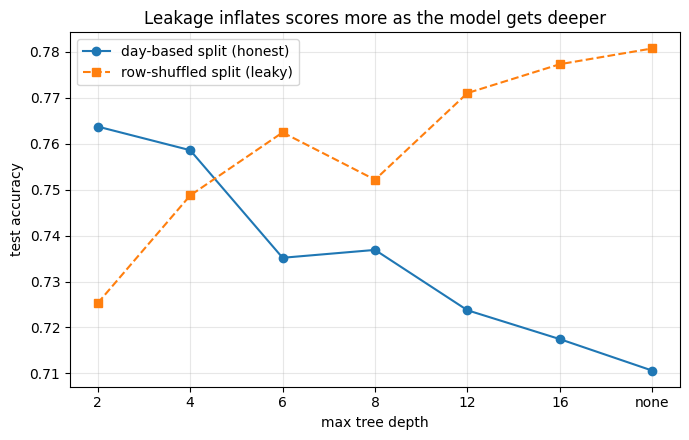

In [ ]:
labels = [str(x) if x is not None else "none" for x in depths]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(labels, honest_scores, "o-", label="day-based split (honest)")
ax.plot(labels, leaky_scores, "s--", label="row-shuffled split (leaky)")
ax.set_xlabel("max tree depth")
ax.set_ylabel("test accuracy")
ax.set_title("Leakage inflates scores more as the model gets deeper")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Model comparison

Six classifiers plus a dummy baseline, on identical splits. Scaling is applied to KNN and SVM only,
inside a `Pipeline` so the scaler learns its statistics from the training portion alone.

In [ ]:
def build_models():
    return {
        "Baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
        "KNN (k=15)":               Pipeline([("sc", StandardScaler()),
                                              ("m", KNeighborsClassifier(n_neighbors=15))]),
        "Decision tree (depth 4)":  DecisionTreeClassifier(max_depth=4, random_state=42),
        "SVM (RBF)":                Pipeline([("sc", StandardScaler()),
                                              ("m", SVC(random_state=42))]),
        "Random forest":            RandomForestClassifier(n_estimators=200, max_depth=8,
                                                           random_state=42, n_jobs=-1),
        "AdaBoost":                 AdaBoostClassifier(n_estimators=200, random_state=42),
        "Voting (tree+SVM+KNN)":    VotingClassifier(estimators=[
            ("tree", DecisionTreeClassifier(max_depth=4, random_state=42)),
            ("svm",  Pipeline([("sc", StandardScaler()), ("m", SVC(random_state=42))])),
            ("knn",  Pipeline([("sc", StandardScaler()),
                               ("m", KNeighborsClassifier(n_neighbors=15))])),
        ], voting="hard"),
    }


def compare_models(target_col, title, features=FEATURES):
    y = d[target_col]
    y_tr, y_te = y[train_mask], y[test_mask]
    Xtr, Xte = d.loc[train_mask, features], d.loc[test_mask, features]

    print(f"\n=== {title} ===")
    results = {}
    for name, model in build_models().items():
        model.fit(Xtr, y_tr)
        acc = model.score(Xte, y_te)
        results[name] = acc
        print(f"  {name:<26} {acc:.3f}")
    return results


res_now    = compare_models("y_now",    "Target A: current output tercile", FEATURES_NOW)
res_future = compare_models("y_future", "Target B: output tercile 6h ahead")
res_ramp   = compare_models("y_ramp",   "Target C: ramp direction over next 6h")


=== Target A: current output tercile ===
  Baseline (most frequent)   0.316
  KNN (k=15)                 0.797
  Decision tree (depth 4)    0.823
  SVM (RBF)                  0.845
  Random forest              0.851
  AdaBoost                   0.800
  Voting (tree+SVM+KNN)      0.842

=== Target B: output tercile 6h ahead ===
  Baseline (most frequent)   0.302
  KNN (k=15)                 0.705
  Decision tree (depth 4)    0.759
  SVM (RBF)                  0.752
  Random forest              0.767
  AdaBoost                   0.747
  Voting (tree+SVM+KNN)      0.750

=== Target C: ramp direction over next 6h ===
  Baseline (most frequent)   0.611
  KNN (k=15)                 0.610
  Decision tree (depth 4)    0.564
  SVM (RBF)                  0.635
  Random forest              0.634
  AdaBoost                   0.626
  Voting (tree+SVM+KNN)      0.635


## 7. Evaluation

Per-class precision, recall and F1 alongside accuracy, since the ramp target is imbalanced 20/60/20
and accuracy alone would not distinguish a useful model from one that never predicts a ramp.


=== A: current tercile ===
              precision    recall  f1-score   support

        high       0.89      0.94      0.91       612
         low       0.84      0.91      0.87       586
         med       0.81      0.69      0.75       554

    accuracy                           0.85      1752
   macro avg       0.85      0.85      0.84      1752
weighted avg       0.85      0.85      0.85      1752



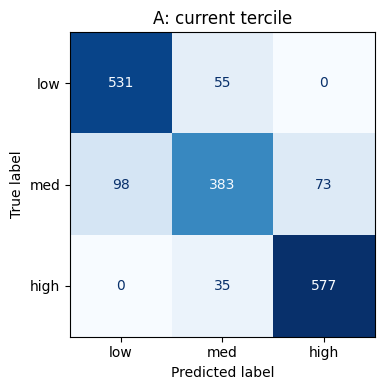


=== B: tercile 6h ahead ===
              precision    recall  f1-score   support

        high       0.81      0.84      0.83       635
         low       0.82      0.84      0.83       588
         med       0.64      0.59      0.61       529

    accuracy                           0.77      1752
   macro avg       0.76      0.76      0.76      1752
weighted avg       0.76      0.77      0.76      1752



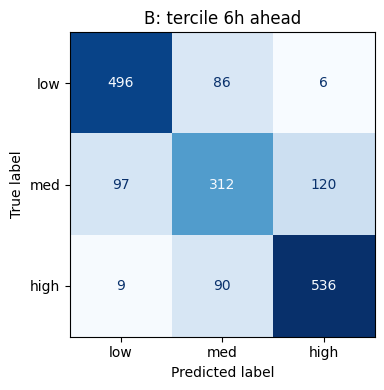


=== C: ramp direction ===
              precision    recall  f1-score   support

        down       0.44      0.44      0.44       304
        flat       0.67      0.86      0.76      1070
          up       0.68      0.13      0.22       378

    accuracy                           0.63      1752
   macro avg       0.60      0.48      0.47      1752
weighted avg       0.63      0.63      0.59      1752



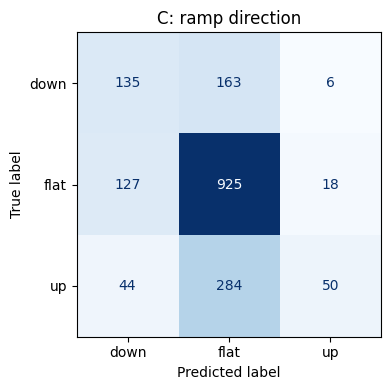

In [ ]:
def evaluate(target_col, title, features=FEATURES, labels=None):
    y = d[target_col]
    y_tr, y_te = y[train_mask], y[test_mask]
    Xtr, Xte = d.loc[train_mask, features], d.loc[test_mask, features]

    model = RandomForestClassifier(n_estimators=200, max_depth=8,
                                   random_state=42, n_jobs=-1)
    model.fit(Xtr, y_tr)
    pred = model.predict(Xte)

    print(f"\n=== {title} ===")
    print(classification_report(y_te, pred, zero_division=0))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, pred, labels=labels, ax=ax,
                                            cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return model


m_now    = evaluate("y_now",    "A: current tercile",   FEATURES_NOW, ["low", "med", "high"])
m_future = evaluate("y_future", "B: tercile 6h ahead",  FEATURES,     ["low", "med", "high"])
m_ramp   = evaluate("y_ramp",   "C: ramp direction",    FEATURES,     ["down", "flat", "up"])

### 7.1 Feature importance

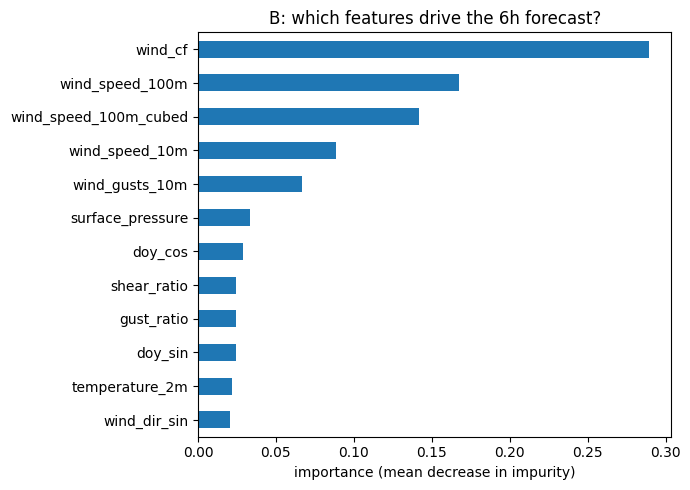

wind_cf                  0.2892
wind_speed_100m          0.1677
wind_speed_100m_cubed    0.1420
wind_speed_10m           0.0884
wind_gusts_10m           0.0665
surface_pressure         0.0332
doy_cos                  0.0291
shear_ratio              0.0246
gust_ratio               0.0243
doy_sin                  0.0243
temperature_2m           0.0217
wind_dir_sin             0.0202
wind_dir_cos             0.0182
cloud_cover              0.0167
shortwave_radiation      0.0139
hour_sin                 0.0117
hour_cos                 0.0080


In [ ]:
def show_importance(model, features, title, top_n=12):
    imp = pd.Series(model.feature_importances_, index=features).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    imp.tail(top_n).plot.barh(ax=ax)
    ax.set_xlabel("importance (mean decrease in impurity)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return imp.sort_values(ascending=False)


imp_future = show_importance(m_future, FEATURES,
                             "B: which features drive the 6h forecast?")
print(imp_future.round(4).to_string())

### 7.2 Feature selection check

Retraining on the top five features by importance, to see how much the remaining twelve contribute.

In [ ]:
top5 = imp_future.head(5).index.tolist()
print("top 5 features:", top5)

rf_all  = RandomForestClassifier(n_estimators=200, max_depth=8,
                                 random_state=42, n_jobs=-1).fit(X_train, y_train)
rf_top5 = RandomForestClassifier(n_estimators=200, max_depth=8,
                                 random_state=42, n_jobs=-1).fit(X_train[top5], y_train)

acc_all  = rf_all.score(X_test, y_test)
acc_top5 = rf_top5.score(X_test[top5], y_test)

print(f"\nall 17 features: {acc_all:.3f}")
print(f"top 5 features:  {acc_top5:.3f}")
print(f"difference:      {acc_top5 - acc_all:+.3f}")

top 5 features: ['wind_cf', 'wind_speed_100m', 'wind_speed_100m_cubed', 'wind_speed_10m', 'wind_gusts_10m']

all 17 features: 0.767
top 5 features:  0.757
difference:      -0.010


### 7.3 Predictions over time

Confusion matrices show how many errors and of what kind, but not whether they come in runs.

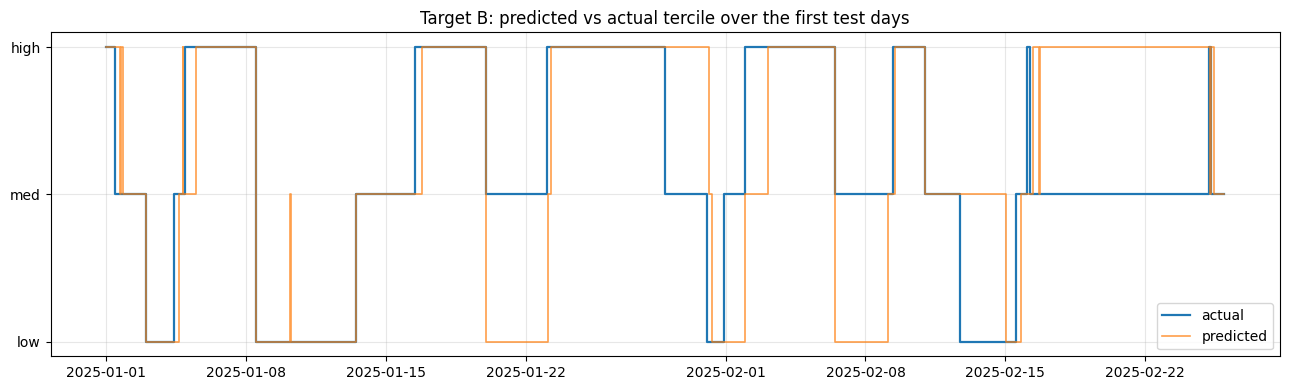

In [ ]:
order = {"low": 0, "med": 1, "high": 2}

test_df = d.loc[test_mask, ["time"]].copy()
test_df["actual"] = y_test.astype(str).map(order).astype(int).values
test_df["predicted"] = pd.Series(m_future.predict(X_test)).astype(str).map(order).astype(int).values
test_df = test_df.sort_values("time").head(14 * 24)   # first ~14 test days

fig, ax = plt.subplots(figsize=(13, 4))
ax.step(test_df["time"], test_df["actual"], where="mid", lw=1.6, label="actual")
ax.step(test_df["time"], test_df["predicted"], where="mid", lw=1.2,
        alpha=0.75, label="predicted")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["low", "med", "high"])
ax.set_title("Target B: predicted vs actual tercile over the first test days")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Rebalancing the ramp classes

Target C reaches its accuracy largely by predicting "flat", which is the safe answer 61% of the
time. `class_weight="balanced"` makes an error on a rare class cost more, in proportion to how rare
it is. The comparison below is about the trade-off, not about finding a higher number.

In [ ]:
y_tr_ramp = d.loc[train_mask, "y_ramp"]
y_te_ramp = d.loc[test_mask,  "y_ramp"]

models = {
    "default":  RandomForestClassifier(n_estimators=200, max_depth=8,
                                      random_state=42, n_jobs=-1),
    "balanced": RandomForestClassifier(n_estimators=200, max_depth=8,
                                      class_weight="balanced",
                                      random_state=42, n_jobs=-1),
}

for name, model in models.items():
    model.fit(X_train, y_tr_ramp)
    pred = model.predict(X_test)
    print(f"--- class_weight = {name} ---")
    print(f"accuracy: {model.score(X_test, y_te_ramp):.3f}")
    print(classification_report(y_te_ramp, pred, zero_division=0))

--- class_weight = default ---
accuracy: 0.634
              precision    recall  f1-score   support

        down       0.44      0.44      0.44       304
        flat       0.67      0.86      0.76      1070
          up       0.68      0.13      0.22       378

    accuracy                           0.63      1752
   macro avg       0.60      0.48      0.47      1752
weighted avg       0.63      0.63      0.59      1752

--- class_weight = balanced ---
accuracy: 0.568
              precision    recall  f1-score   support

        down       0.37      0.73      0.49       304
        flat       0.79      0.58      0.67      1070
          up       0.42      0.40      0.41       378

    accuracy                           0.57      1752
   macro avg       0.53      0.57      0.52      1752
weighted avg       0.63      0.57      0.58      1752



## 8. Hyperparameter tuning

**This cell takes around 6 minutes** (30 combinations x 5 folds x 200 trees).

`GroupKFold` rather than plain `KFold`, passing the calendar day as the group, so the tuning loop
does not reintroduce the leakage measured in section 5.1.

In [ ]:
groups = d.loc[train_mask, "day"]

param_grid = {
    "max_depth": [4, 6, 8, 12, None],
    "min_samples_leaf": [1, 5, 20],
    "max_features": ["sqrt", 0.5],
}

search = GridSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    param_grid,
    cv=GroupKFold(n_splits=5),
    scoring="accuracy",
    n_jobs=-1,
)
search.fit(X_train, y_train, groups=groups)

print("best params:", search.best_params_)
print(f"best CV accuracy:  {search.best_score_:.3f}")
print(f"held-out test acc: {search.score(X_test, y_test):.3f}")
print(f"untuned test acc:  {m_future.score(X_test, y_test):.3f}")

cv = pd.DataFrame(search.cv_results_)
print("\ntop 5 configurations:")
print(cv.nlargest(5, "mean_test_score")[
    ["param_max_depth", "param_min_samples_leaf", "param_max_features",
     "mean_test_score", "std_test_score"]].to_string(index=False))

best params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1}
best CV accuracy:  0.746
held-out test acc: 0.767
untuned test acc:  0.767

top 5 configurations:
param_max_depth  param_min_samples_leaf param_max_features  mean_test_score  std_test_score
              8                       1               sqrt         0.745591        0.020162
             12                       1               sqrt         0.745224        0.016113
              6                      20                0.5         0.745059        0.020315
             12                       5               sqrt         0.744908        0.016309
             12                      20               sqrt         0.744196        0.020034


## 9. Summary of results

In [ ]:
rows = []
for target, name, feats in [("y_now",    "A: current tercile",  FEATURES_NOW),
                            ("y_future", "B: tercile 6h ahead", FEATURES),
                            ("y_ramp",   "C: ramp direction",   FEATURES)]:
    y = d[target]
    y_tr, y_te = y[train_mask], y[test_mask]
    Xtr, Xte = d.loc[train_mask, feats], d.loc[test_mask, feats]

    dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, y_tr)
    rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                                random_state=42, n_jobs=-1).fit(Xtr, y_tr)
    pred = rf.predict(Xte)

    rows.append({
        "target":       name,
        "baseline acc": round(dummy.score(Xte, y_te), 3),
        "model acc":    round(rf.score(Xte, y_te), 3),
        "gain":         round(rf.score(Xte, y_te) - dummy.score(Xte, y_te), 3),
        "macro F1":     round(f1_score(y_te, pred, average="macro"), 3),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

             target  baseline acc  model acc  gain  macro F1
 A: current tercile         0.316      0.851 0.535     0.845
B: tercile 6h ahead         0.302      0.767 0.465     0.758
  C: ramp direction         0.611      0.634 0.023     0.474


## 10. Interactive forecast tool

Sliders for the main inputs, with the predicted class and the model's confidence across all three
classes.

In [ ]:
final_model = RandomForestClassifier(n_estimators=200, max_depth=8,
                                     random_state=42, n_jobs=-1)
final_model.fit(d[FEATURES], d["y_future"])

med = d[FEATURES].median()
style = {"description_width": "140px"}

w_speed100 = widgets.FloatSlider(value=med["wind_speed_100m"], min=0, max=25, step=0.5,
                                 description="wind 100m (m/s)", style=style)
w_speed10  = widgets.FloatSlider(value=med["wind_speed_10m"], min=0, max=20, step=0.5,
                                 description="wind 10m (m/s)", style=style)
w_press    = widgets.FloatSlider(value=med["surface_pressure"], min=950, max=1050, step=1,
                                 description="pressure (hPa)", style=style)
w_temp     = widgets.FloatSlider(value=med["temperature_2m"], min=-5, max=30, step=0.5,
                                 description="temperature (C)", style=style)
w_cf       = widgets.FloatSlider(value=med["wind_cf"], min=0, max=1, step=0.01,
                                 description="current output", style=style)
out = widgets.Output()


def predict(change=None):
    row = med.copy()
    row["wind_speed_100m"]  = w_speed100.value
    row["wind_speed_10m"]   = w_speed10.value
    row["surface_pressure"] = w_press.value
    row["temperature_2m"]   = w_temp.value
    row["wind_cf"]          = w_cf.value
    row["wind_speed_100m_cubed"] = w_speed100.value ** 3
    row["shear_ratio"] = w_speed100.value / max(w_speed10.value, 0.1)

    X_one = pd.DataFrame([row])[FEATURES]
    pred = final_model.predict(X_one)[0]
    proba = final_model.predict_proba(X_one)[0]

    with out:
        out.clear_output()
        print(f"Forecast for 6 hours ahead:  {pred.upper()}\n")
        for cls, prob in zip(final_model.classes_, proba):
            print(f"  {cls:>5}  {prob:5.1%}  {'#' * int(prob * 40)}")


for w in [w_speed100, w_speed10, w_press, w_temp, w_cf]:
    w.observe(predict, names="value")

display(widgets.VBox([w_speed100, w_speed10, w_press, w_temp, w_cf, out]))
predict()